<a href="https://colab.research.google.com/github/abhinavaby/3D-camer-Tracking/blob/main/day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pillow

from PIL import Image, ImageChops, ImageEnhance, ImageFilter
import matplotlib.pyplot as plt

Saving 860_main_beauty.png.webp to 860_main_beauty.png (1).webp


Saving closeup-shot-beautiful-butterfly-with-interesting-textures-orange-petaled-flower_181624-7640.jpg.avif to closeup-shot-beautiful-butterfly-with-interesting-textures-orange-petaled-flower_181624-7640.jpg (1).avif


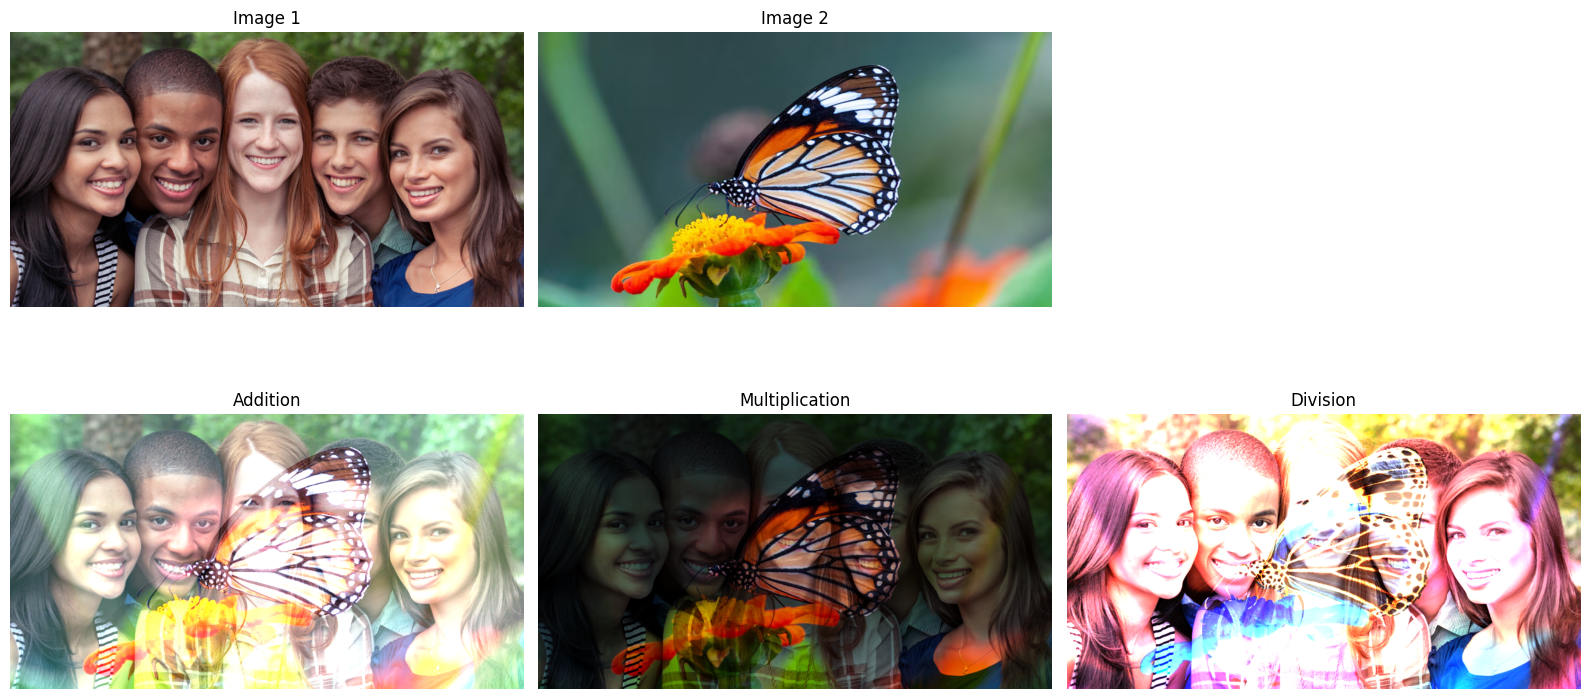

In [4]:
from PIL import Image
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

# Upload first image
uploaded = files.upload()
img1 = Image.open(next(iter(uploaded))).convert("RGB")

# Upload second image
uploaded = files.upload()
img2 = Image.open(next(iter(uploaded))).convert("RGB")

# Resize second image to match first image
img2 = img2.resize(img1.size)

# Convert images to NumPy arrays
arr1 = np.array(img1, dtype=np.float32)
arr2 = np.array(img2, dtype=np.float32)

# ----------------------------
# Addition
# ----------------------------
add_img = np.clip(arr1 + arr2, 0, 255).astype(np.uint8)

# ----------------------------
# Multiplication
# ----------------------------
multiply_img = np.clip((arr1 * arr2) / 255, 0, 255).astype(np.uint8)

# ----------------------------
# Division
# ----------------------------
# Add 1 to avoid division by zero
division_img = np.clip((arr1 / (arr2 + 1)) * 255, 0, 255).astype(np.uint8)

# Convert arrays back to images
add_img = Image.fromarray(add_img)
multiply_img = Image.fromarray(multiply_img)
division_img = Image.fromarray(division_img)

# Display results
plt.figure(figsize=(16,8))

plt.subplot(2,3,1)
plt.imshow(img1)
plt.title("Image 1")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(img2)
plt.title("Image 2")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(add_img)
plt.title("Addition")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(multiply_img)
plt.title("Multiplication")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(division_img)
plt.title("Division")
plt.axis("off")

plt.tight_layout()
plt.show()

Upload First Image


Saving closeup-shot-beautiful-butterfly-with-interesting-textures-orange-petaled-flower_181624-7640.jpg.avif to closeup-shot-beautiful-butterfly-with-interesting-textures-orange-petaled-flower_181624-7640.jpg (2).avif
Upload Second Image


Saving 860_main_beauty.png.webp to 860_main_beauty.png (2).webp


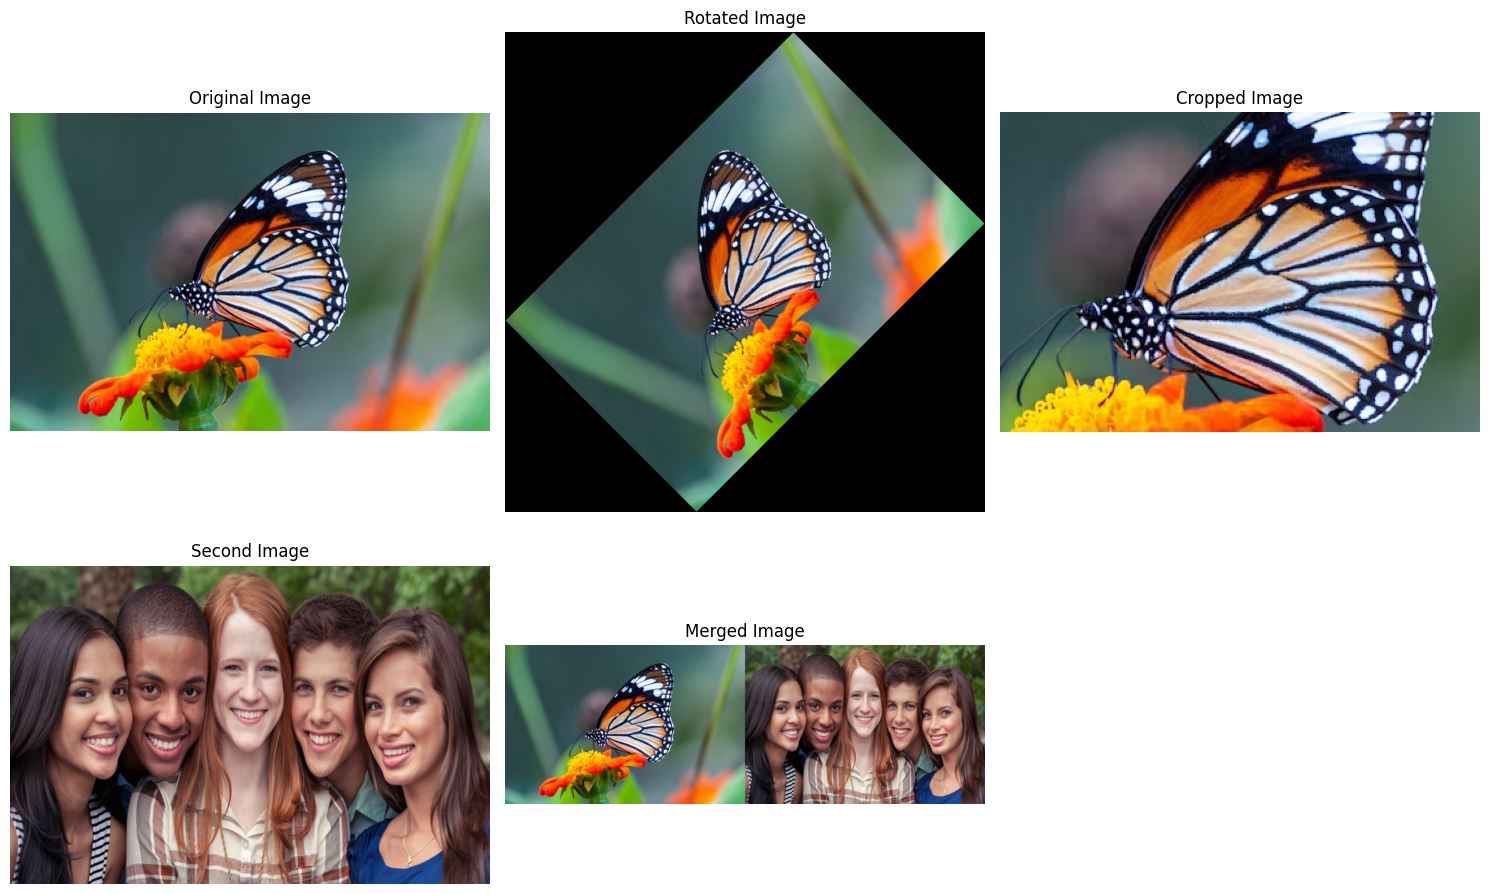

In [5]:
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt

# Upload first image
print("Upload First Image")
uploaded = files.upload()
img1 = Image.open(next(iter(uploaded))).convert("RGB")

# Upload second image
print("Upload Second Image")
uploaded = files.upload()
img2 = Image.open(next(iter(uploaded))).convert("RGB")

# -----------------------------
# 1. Rotate Image
# -----------------------------
rotated = img1.rotate(45, expand=True)

# -----------------------------
# 2. Crop Image
# crop(left, top, right, bottom)
# -----------------------------
width, height = img1.size

cropped = img1.crop((
    width//4,
    height//4,
    3*width//4,
    3*height//4
))

# -----------------------------
# 3. Merge Images Side-by-Side
# -----------------------------
img2 = img2.resize(img1.size)

merged = Image.new(
    "RGB",
    (img1.width + img2.width, img1.height)
)

merged.paste(img1, (0, 0))
merged.paste(img2, (img1.width, 0))

# -----------------------------
# Display Results
# -----------------------------
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(img1)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(rotated)
plt.title("Rotated Image")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(cropped)
plt.title("Cropped Image")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(img2)
plt.title("Second Image")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(merged)
plt.title("Merged Image")
plt.axis("off")

plt.tight_layout()
plt.show()

Upload First Image


Saving 860_main_beauty.png.webp to 860_main_beauty.png (3).webp
Upload Second Image


Saving closeup-shot-beautiful-butterfly-with-interesting-textures-orange-petaled-flower_181624-7640.jpg.avif to closeup-shot-beautiful-butterfly-with-interesting-textures-orange-petaled-flower_181624-7640.jpg (3).avif


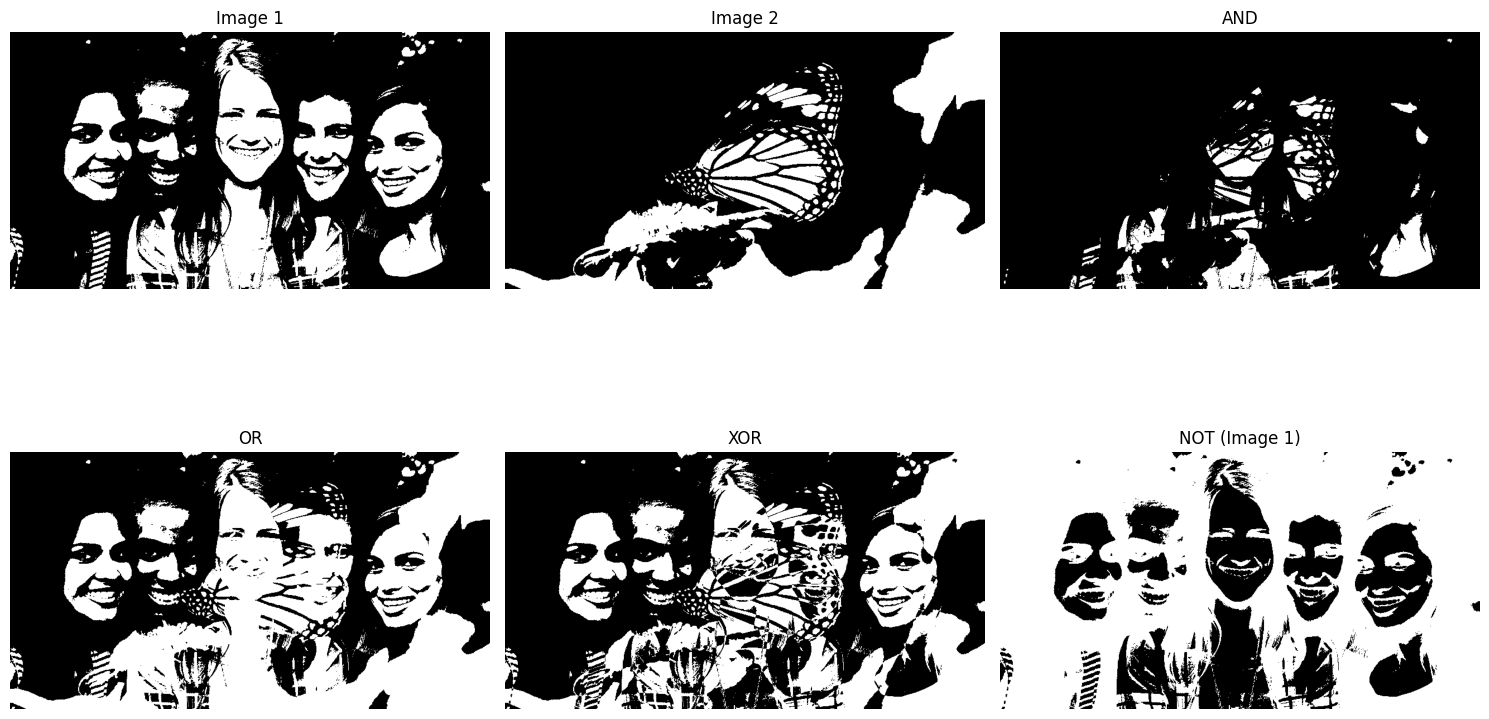

In [6]:
from PIL import Image
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

# Upload first image
print("Upload First Image")
uploaded = files.upload()
img1 = Image.open(next(iter(uploaded))).convert('L')

# Upload second image
print("Upload Second Image")
uploaded = files.upload()
img2 = Image.open(next(iter(uploaded))).convert('L')

# Resize second image to match first image
img2 = img2.resize(img1.size)

# Convert images to NumPy arrays
img1_np = np.array(img1)
img2_np = np.array(img2)

# Convert to binary images (0 or 255)
img1_bin = np.where(img1_np > 127, 255, 0).astype(np.uint8)
img2_bin = np.where(img2_np > 127, 255, 0).astype(np.uint8)

# Logical Operations
and_img = np.bitwise_and(img1_bin, img2_bin)
or_img  = np.bitwise_or(img1_bin, img2_bin)
xor_img = np.bitwise_xor(img1_bin, img2_bin)
not_img = np.bitwise_not(img1_bin)

# Display Results
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(img1_bin, cmap='gray')
plt.title("Image 1")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(img2_bin, cmap='gray')
plt.title("Image 2")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(and_img, cmap='gray')
plt.title("AND")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(or_img, cmap='gray')
plt.title("OR")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(xor_img, cmap='gray')
plt.title("XOR")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(not_img, cmap='gray')
plt.title("NOT (Image 1)")
plt.axis("off")

plt.tight_layout()
plt.show()

Upload First Image


Saving closeup-shot-beautiful-butterfly-with-interesting-textures-orange-petaled-flower_181624-7640.jpg.avif to closeup-shot-beautiful-butterfly-with-interesting-textures-orange-petaled-flower_181624-7640.jpg (4).avif
Upload Second Image


Saving 860_main_beauty.png.webp to 860_main_beauty.png (4).webp


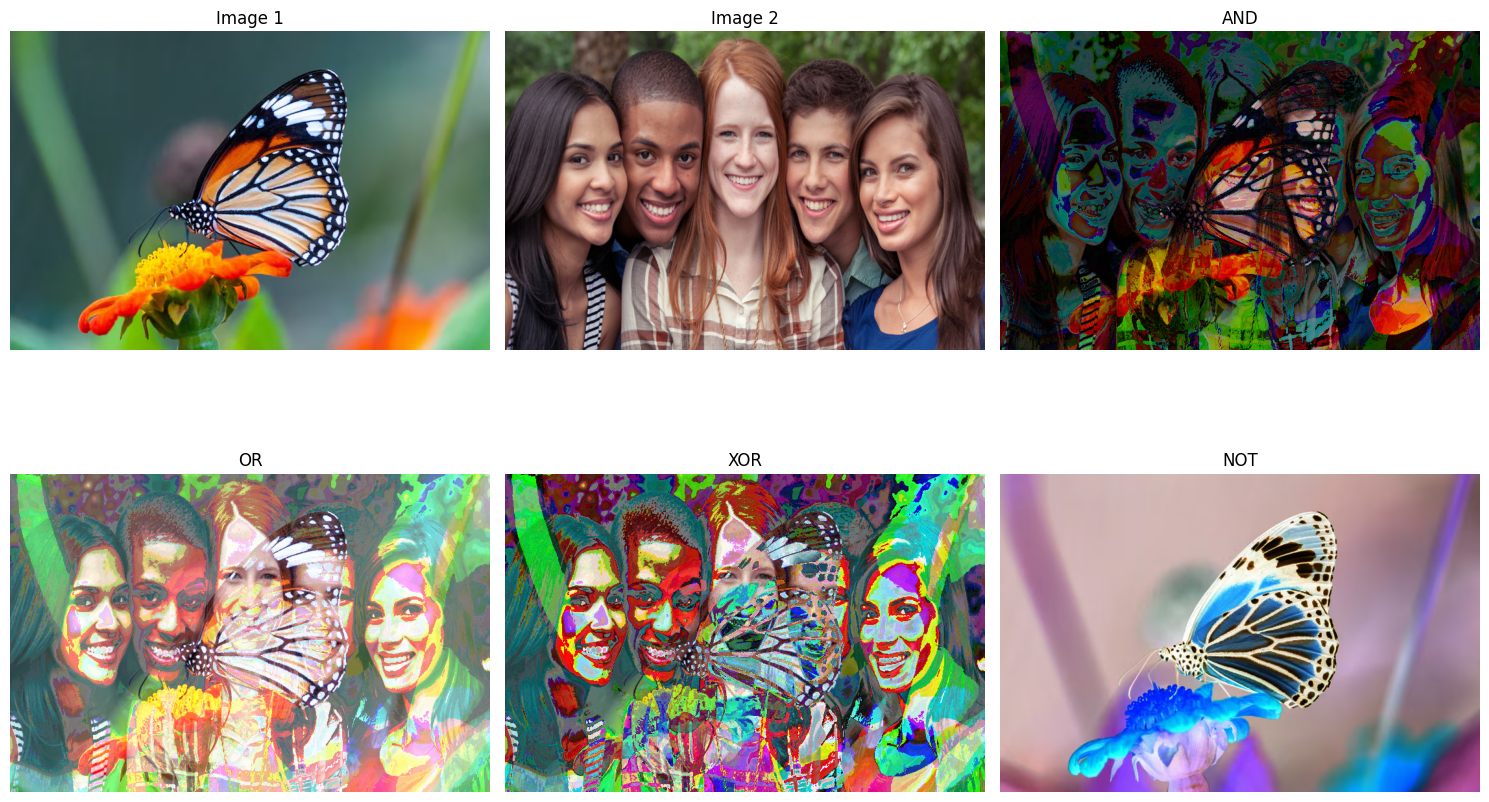

In [7]:
from PIL import Image
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

# Upload first image
print("Upload First Image")
uploaded = files.upload()
img1 = Image.open(next(iter(uploaded))).convert("RGB")

# Upload second image
print("Upload Second Image")
uploaded = files.upload()
img2 = Image.open(next(iter(uploaded))).convert("RGB")

# Resize second image to match first image
img2 = img2.resize(img1.size)

# Convert images to NumPy arrays
img1_np = np.array(img1)
img2_np = np.array(img2)

# Logical Operations on RGB channels
and_img = np.bitwise_and(img1_np, img2_np)
or_img  = np.bitwise_or(img1_np, img2_np)
xor_img = np.bitwise_xor(img1_np, img2_np)
not_img = np.bitwise_not(img1_np)

# Display Results
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(img1)
plt.title("Image 1")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(img2)
plt.title("Image 2")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(and_img)
plt.title("AND")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(or_img)
plt.title("OR")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(xor_img)
plt.title("XOR")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(not_img)
plt.title("NOT")
plt.axis("off")

plt.tight_layout()
plt.show()

Saving 860_main_beauty.png.webp to 860_main_beauty.png (5).webp


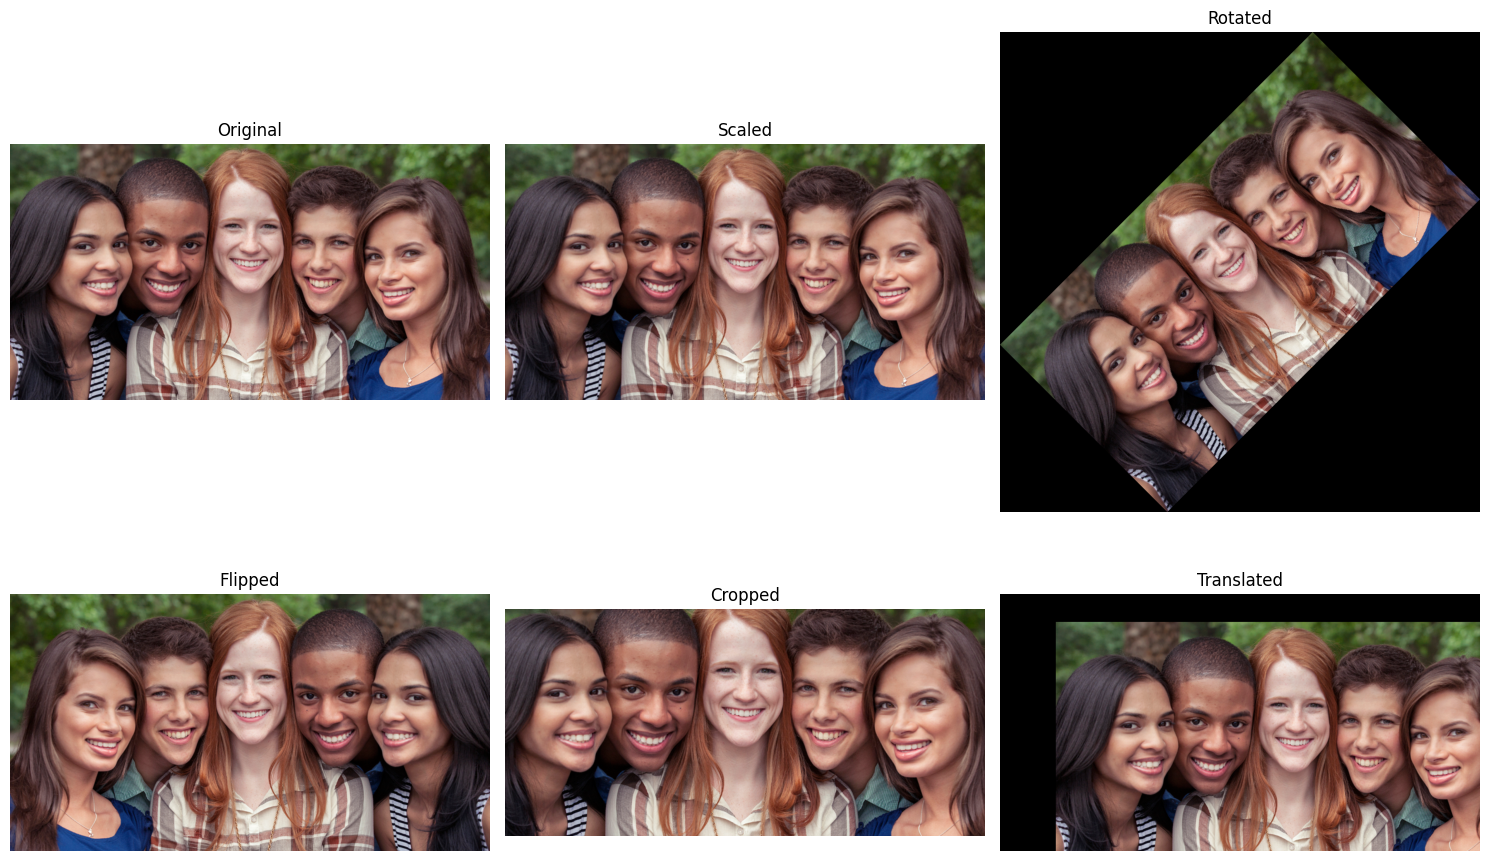

In [8]:
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()
img = Image.open(next(iter(uploaded))).convert("RGB")

# -------------------------
# 1. Scaling (Resize)
# -------------------------
scaled = img.resize(
    (int(img.width * 1.5), int(img.height * 1.5))
)

# -------------------------
# 2. Rotation
# -------------------------
rotated = img.rotate(45, expand=True)

# -------------------------
# 3. Horizontal Flip
# -------------------------
flipped = img.transpose(Image.FLIP_LEFT_RIGHT)

# -------------------------
# 4. Cropping
# -------------------------
cropped = img.crop(
    (50, 50, img.width - 50, img.height - 50)
)

# -------------------------
# 5. Translation (Shift)
# -------------------------
translated = Image.new("RGB", img.size)

shift_x = 100
shift_y = 50

translated.paste(img, (shift_x, shift_y))

# -------------------------
# Display Results
# -------------------------
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(scaled)
plt.title("Scaled")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(rotated)
plt.title("Rotated")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(flipped)
plt.title("Flipped")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(cropped)
plt.title("Cropped")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(translated)
plt.title("Translated")
plt.axis("off")

plt.tight_layout()
plt.show()